In [2]:
import pandas as pd

commit = pd.read_csv("Commit.csv")

races = pd.read_csv("Nemo.csv")

forcedecks = pd.read_csv("Forcedeck.csv")

In [3]:
#Get rid of rows that will mess with signal (non-real races)
races = races[  
~races["CompetitionName"].isin(["Training", "Certification 2026", "CERTIFICATION 2025", "CERTIFICATION 2023", "CERTIFICATION 2022"])  
]

In [44]:
#Only grab rows that are labelled as "CMJ" Test Type

fd_cmj = forcedecks[forcedecks["Test Type"] == "CMJ"].copy()

#Standardise Athlete Id label and datetime

fd_cmj["athlete_id"] = fd_cmj["About"]
fd_cmj["timestamp"] = pd.to_datetime(fd_cmj["Date"], dayfirst=True, utc=True, errors="coerce")

In [45]:
#Standardise Athlete Id label and datetime

races["athlete_id"] = races["AthleteName"]
races["race_date"] = pd.to_datetime(races["Date"], errors = "coerce", dayfirst=True, utc=True)

races = races.copy()

In [46]:
#Specify races window to only include races with prior CMJ data

min_cmj = fd_cmj["timestamp"].min()
races_in_range = races[pd.to_datetime(races["race_date"], utc = True) >= min_cmj].copy()

In [47]:
#Choose 50 meter races only

races_50 = races[races["RaceEventDistance"] == 50].copy()

In [49]:
# Build a matched dataset by pairing each 50m race with the most recent CMJ test that occured BEFORE the race

rows = []

for _, r in races_50.iterrows():

    #get all CMJ records for the athlete
    athlete_data = fd_cmj[fd_cmj["athlete_id"] == r["athlete_id"]]

    #only keep CMJs that occured before the race
    before = athlete_data[athlete_data["timestamp"] < r["race_date"]]

    # skip if no CMJ
    if len(before) == 0:
        continue  

    #Most recent CMJ
    latest = before.sort_values("timestamp").iloc[-1]

    #Store the pair (CMJ x Race)
    rows.append({
        "race_time": r["RaceTime"],
        "jump_height": latest["Jump Height (Flight Time) [cm]"],
        "peak_power": latest["Peak Power / BM [W/kg]"]
    })

df = pd.DataFrame(rows)

In [10]:
df.shape

(87, 3)

In [50]:
#Fit linear regression on the dataframe

from sklearn.linear_model import LinearRegression

X = df[["jump_height", "peak_power"]]
y = df["race_time"]

model = LinearRegression()
model.fit(X, y)

print("R²:", model.score(X, y))

R²: 0.1444744980589462


In [51]:
#Only narrow it down to 50 free to avoid "stroke" as a covariant

races_50_free = races[
    (races["RaceEventDistance"] == 50) &
    (races["RaceEventSwimmingStyleName"] == "Freestyle")
].copy()

In [13]:
rows = []

for _, r in races_50_free.iterrows():

    athlete_data = fd_cmj[fd_cmj["athlete_id"] == r["athlete_id"]]
    before = athlete_data[athlete_data["timestamp"] < r["race_date"]]

    if len(before) == 0:
        continue  # skip if no CMJ

    latest = before.sort_values("timestamp").iloc[-1]

    rows.append({
        "race_time": r["RaceTime"],
        "jump_height": latest["Jump Height (Flight Time) [cm]"],
        "peak_power": latest["Peak Power / BM [W/kg]"]
    })

df = pd.DataFrame(rows)

In [14]:
df.shape

(8, 3)

In [15]:
from sklearn.linear_model import LinearRegression

X = df[["jump_height", "peak_power"]]
y = df["race_time"]

model = LinearRegression()
model.fit(X, y)

print("R²:", model.score(X, y))

R²: 0.8955777698041791


In [16]:
!pip install matplotlib


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: C:\Users\adhamz\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


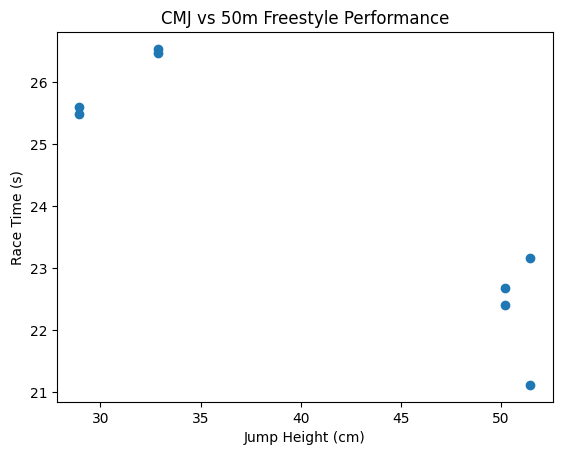

In [17]:
import matplotlib.pyplot as plt

plt.scatter(df["jump_height"], df["race_time"])
plt.xlabel("Jump Height (cm)")
plt.ylabel("Race Time (s)")
plt.title("CMJ vs 50m Freestyle Performance")
plt.show()

In [41]:
#8 datapoints is too low
#Checking:

races_50_free = races[
    (races["RaceEventDistance"] == 50) &
    (races["RaceEventSwimmingStyleName"] == "Freestyle")
].copy()

races_50_free.shape

(99, 764)

In [21]:
races_50_free["race_date"].min(), races_50_free["race_date"].max()

(Timestamp('2022-02-26 00:00:00+0000', tz='UTC'),
 Timestamp('2025-12-13 00:00:00+0000', tz='UTC'))

In [22]:
fd_cmj["timestamp"].min(), fd_cmj["timestamp"].max()

(Timestamp('2023-10-18 00:00:00+0000', tz='UTC'),
 Timestamp('2025-12-10 00:00:00+0000', tz='UTC'))

In [23]:
race_names = set(races_50_free["athlete_id"].dropna().unique())
cmj_names = set(fd_cmj["athlete_id"].dropna().unique())

len(race_names), len(cmj_names), len(race_names & cmj_names)

(12, 11, 6)

In [24]:
matched_athletes = race_names & cmj_names

races_50_free_matched = races_50_free[
    races_50_free["athlete_id"].isin(matched_athletes)
]

races_50_free_matched.shape

(24, 764)

In [25]:
races_50_free_matched[
    races_50_free_matched["race_date"] >= fd_cmj["timestamp"].min()
].shape

(13, 764)

In [26]:
sorted(race_names - cmj_names)

['Abby Kane',
 'Evan Jones',
 'Evelyn Davis',
 'Jamie Robertson',
 'Lucy Hope',
 'Thomas Dean']

In [27]:
sorted(cmj_names - race_names)

['Angharad Evans',
 'David Annis',
 'George Smith',
 'Holly McGill',
 'Keanna MacInnes']

In [28]:
races_50_free[
    races_50_free["race_date"] >= fd_cmj["timestamp"].min()
].shape

(50, 764)

In [29]:
def clean_name(x):
    return (
        str(x)
        .lower()
        .strip()
        .replace(",", "")
        .replace("  ", " ")
    )

races_50_free["athlete_key"] = races_50_free["athlete_id"].apply(clean_name)
fd_cmj["athlete_key"] = fd_cmj["athlete_id"].apply(clean_name)

race_names_clean = set(races_50_free["athlete_key"].dropna().unique())
cmj_names_clean = set(fd_cmj["athlete_key"].dropna().unique())

len(race_names_clean), len(cmj_names_clean), len(race_names_clean & cmj_names_clean)

(12, 11, 6)

In [30]:
for athlete in matched_athletes:

    athlete_races = races_50_free[
        races_50_free["athlete_id"] == athlete
    ].sort_values("race_date")

    athlete_cmj = fd_cmj[
        fd_cmj["athlete_id"] == athlete
    ].sort_values("timestamp")

    print("\nATHLETE:", athlete)
    print("RACES:")
    print(athlete_races["race_date"].head())

    print("FIRST CMJ:")
    print(athlete_cmj["timestamp"].min())


ATHLETE: Katie Shanahan
RACES:
764    2024-03-08 00:00:00+00:00
1271   2024-03-08 00:00:00+00:00
Name: race_date, dtype: datetime64[us, UTC]
FIRST CMJ:
2023-11-16 00:00:00+00:00

ATHLETE: Duncan Scott
RACES:
1654   2022-06-16 00:00:00+00:00
1840   2023-12-05 00:00:00+00:00
316    2024-03-09 00:00:00+00:00
2061   2024-03-09 00:00:00+00:00
Name: race_date, dtype: datetime64[us, UTC]
FIRST CMJ:
2023-11-17 00:00:00+00:00

ATHLETE: Freya Anderson
RACES:
104    2022-12-04 00:00:00+00:00
1164   2022-12-04 00:00:00+00:00
879    2023-03-10 00:00:00+00:00
1855   2023-03-10 00:00:00+00:00
534    2023-12-05 00:00:00+00:00
Name: race_date, dtype: datetime64[us, UTC]
FIRST CMJ:
2025-02-17 00:00:00+00:00

ATHLETE: Lucy Grieve
RACES:
852    2022-03-11 00:00:00+00:00
455    2022-04-07 00:00:00+00:00
149    2022-07-25 00:00:00+00:00
1227   2022-07-25 00:00:00+00:00
615    2023-02-25 00:00:00+00:00
Name: race_date, dtype: datetime64[us, UTC]
FIRST CMJ:
2023-10-18 00:00:00+00:00

ATHLETE: Jack McMillan
R

In [31]:
races_after = races_50_free[
    races_50_free["race_date"] >= fd_cmj["timestamp"].min()
]

races_after.shape

(50, 765)

In [32]:
races_after["athlete_id"].value_counts()

athlete_id
Evelyn Davis       23
Lucy Hope          10
Freya Anderson      5
Duncan Scott        3
Dean Fearn          2
Evan Jones          2
Katie Shanahan      2
Jack McMillan       1
Jamie Robertson     1
Abby Kane           1
Name: count, dtype: int64

In [33]:
races_after[
    races_after["athlete_id"].isin(matched_athletes)
]["athlete_id"].value_counts()

athlete_id
Freya Anderson    5
Duncan Scott      3
Dean Fearn        2
Katie Shanahan    2
Jack McMillan     1
Name: count, dtype: int64